## 授權與來源（License & Attribution）

本課程自編／改編的程式與文字：Copyright 2026 leonjyentub；Apache License 2.0（`../LICENSE`）。
教學概念與來源參照：Aurélien Géron, `ageron/handson-mlp` Ch.15 Transformer，上游 Apache-2.0，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`。
本檔改編／創作說明：依原書概念另編可於 CPU 執行的小型機制實驗、示範圖表與中文教學解釋；不等同於完整上游實驗，亦不表示每段程式均直接複製上游。
詳細對照：`../SOURCES.md`；授權及署名：`../THIRD_PARTY_NOTICES.md`。
其他第三方資料、圖片及模型權利按各自來源處理，不包含在本課程程式授權中。

# 18｜Transformer_注意力架構與預訓練

位置編碼加上 causal mask，驗證第 t 個 token 不會看到未來。

對應 `slides/18_Transformer_注意力架構與預訓練.md`；從第一格依序執行即可重現投影片中的表格與圖。

## 來源與改編界線

- Aurélien Géron，`handson-mlp/15_transformers_for_nlp_and_chatbots.ipynb`，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`，參考 Cells 31、35、46（位置編碼、遮罩、多頭注意力）。

- 本 Notebook 為課堂短實驗：保留核心張量、演算法或評估流程，改用 NumPy／scikit-learn 與小型資料，讓 CPU 能快速重跑。
- 圖表與數值是本檔實際執行結果，不代表原書完整模型成效。原始程式授權與歸屬見 `../NOTICE.md`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import SEED, setup, savefig, report
setup()
rng = np.random.default_rng(SEED)

## 課堂小實驗

In [2]:
n, d = 6, 4
pos = np.arange(n)[:, None]
freq = np.exp(np.arange(0, d, 2) * (-np.log(10000.0) / d))
pe = np.zeros((n, d)); pe[:, 0::2] = np.sin(pos * freq); pe[:, 1::2] = np.cos(pos * freq)
scores = pe @ pe.T / np.sqrt(d)
causal_mask = np.triu(np.ones((n, n), dtype=bool), k=1)
masked = np.where(causal_mask, -1e9, scores)
weights = np.exp(masked - masked.max(axis=1, keepdims=True)); weights /= weights.sum(1, keepdims=True)
print('future attention mass:', weights[causal_mask].sum())
pd.DataFrame(weights).round(3)

future attention mass: 0.0


,0,1,2,3,4,5
0,1.000,0.000,0.000,0.000,0.000,0.000
1,0.443,0.557,0.000,0.000,0.000,0.000
2,0.215,0.347,0.437,0.000,0.000,0.000
3,0.139,0.185,0.299,0.376,0.000,0.000
4,0.141,0.119,0.159,0.257,0.323,0.000
5,0.184,0.115,0.097,0.130,0.210,0.264


## 執行結果圖

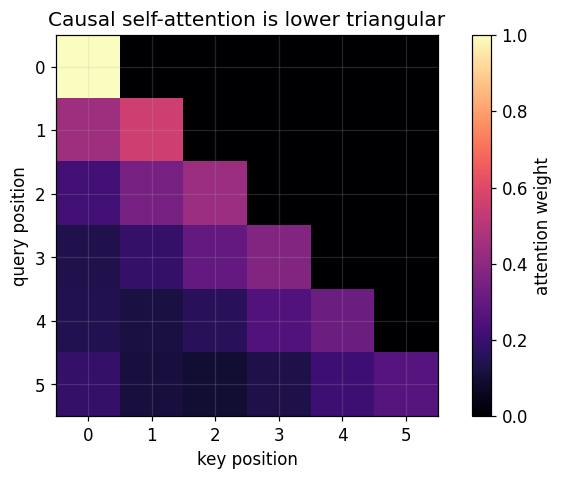

In [3]:
plt.imshow(weights, cmap='magma', vmin=0, vmax=1)
plt.colorbar(label='attention weight'); plt.xlabel('key position'); plt.ylabel('query position')
plt.title('Causal self-attention is lower triangular')
savefig('18_transformer_mask_demo')
report('transformer_mask', {'future_mass': weights[causal_mask].sum(), 'weights': weights.tolist()})

## 解讀與延伸

先描述圖或表直接支持的結果，再說明這個縮編實驗不能代表完整模型的哪些面向。